# Medical Anomaly Detection — Jev

## 1. Install & keys

In [ ]:
!pip install -q -U openai requests pydantic pandas scikit-learn matplotlib

!pip install typesafe_sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 50.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os, getpass
for k in ["OPENROUTER_API_KEY", "OPENAI_API_KEY"]:
    try:
        from google.colab import userdata
        os.environ[k] = userdata.get(k)
    except Exception:
        pass
    if not os.environ.get(k):
        os.environ[k] = getpass.getpass(f"{k}: ")
OR_KEY  = os.environ["OPENROUTER_API_KEY"]
OR_BASE = "https://openrouter.ai/api/v1"
print("Keys loaded")

Keys loaded


## 2. Config


In [ ]:
JEV_MODEL     = "typesafe/jev-1.13"
LLM_MODELS    = ["gpt-4.1-mini"]
LOGPROB_MODEL = "gpt-4.1-mini"
TEMPERATURE   = 0
MAX_WORKERS   = 8

OPENAI_PRICE = {
    "gpt-4.1-mini": {"in": None, "out": None},
}

## 3. Shared question design

In [ ]:
import json, math, time
import numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor

SEVERITY = {
    "none":     "No clinical concern; expected for this patient.",
    "low":      "Minor deviation; routine follow-up.",
    "moderate": "Clinically relevant; review within hours.",
    "high":     "Serious; prompt clinician review needed.",
    "critical": "Potentially life-threatening; immediate action.",
}
SEV_NAMES = list(SEVERITY)

DOMAINS = {
    "labs": {
        "none":              "Within range, or abnormal but fully explained by the patient's known baseline or condition.",
        "critical_value":    "A result in a critical/panic range needing urgent action.",
        "significant_trend": "Clinically important change from the patient's own previous values.",
        "specimen_artifact": "Result likely spurious due to sample handling (e.g. haemolysis, contamination).",
    },
    "vitals": {
        "none":                 "Stable or explained by the patient's known baseline, medication or condition.",
        "deterioration":        "Pattern across readings suggesting clinical deterioration (e.g. sepsis, respiratory failure).",
        "abnormal_value":       "A single-parameter value dangerously out of range.",
        "measurement_artifact": "Reading likely caused by sensor/measurement error rather than the patient.",
    },
    "meds": {
        "none":                     "Appropriate order for this patient.",
        "dosing_error":             "Dose, frequency or units wrong for the drug or patient (weight, age, renal function).",
        "allergy_contraindication": "Conflicts with a documented allergy or contraindication.",
        "drug_interaction":         "Dangerous interaction or therapeutic duplication with current medications.",
    },
    "discharge": {
        "none":                        "Safe, appropriate discharge; summary is complete and internally consistent.",
        "unsafe_discharge":            "Patient discharged while clinically unstable or with an unaddressed dangerous finding.",
        "medication_error":            "Discharge medication list has a wrong dose/frequency, dangerous omission, duplication, allergy conflict or contraindication.",
        "documentation_inconsistency": "Summary contradicts itself (side, dates, allergies, diagnoses vs treatment).",
        "missing_follow_up":           "A significant finding or pending result has no follow-up plan or responsible owner.",
    },
}

Q_TEXT = {
    "is_anomaly":    "This clinical event is anomalous: abnormal for THIS patient in a way a clinician should know about "
                     "(including likely artifacts). Values explained by the patient's documented baseline or condition are NOT anomalous.",
    "anomaly_type":  "Which category best describes this event?",
    "severity":      "How clinically severe is this event for this patient?",
    "urgent_review": "A clinician should review this event within the next hour.",
}

Q_OVERRIDE = {
    "discharge": {
        "is_anomaly": "This discharge summary contains a patient-safety problem: unsafe discharge, medication error, "
                      "internal contradiction, or a significant finding/pending result without follow-up. "
                      "A complete, consistent summary of an appropriate discharge is NOT anomalous. "
                      "Values at the patient's documented baseline are NOT anomalous.",
        "urgent_review": "A clinician should act on this discharge summary today (e.g. recall the patient or correct the prescription).",
    },
}

def q(key, domain): return Q_OVERRIDE.get(domain, {}).get(key, Q_TEXT[key])

def as_text(state): return state if isinstance(state, str) else json.dumps(state)


## 4. Load discharge summaries from CSV

In [ ]:
CSV_PATH = "discharge_summaries.csv"

USE_BUILTIN_CASES = True

if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print("Upload discharge_summaries.csv …")
        up = files.upload()
        CSV_PATH = next(iter(up))
    except ImportError:
        raise FileNotFoundError(CSV_PATH)

ds = pd.read_csv(CSV_PATH)
required = {"domain", "label", "exp_type", "discharge_summary"}
assert required <= set(ds.columns), f"missing columns: {required - set(ds.columns)}"
bad = set(ds.exp_type) - set(DOMAINS["discharge"])
assert not bad, f"exp_type not in DOMAINS['discharge']: {bad}"

csv_cases = [case(r.domain, r.discharge_summary, int(r.label), r.exp_type) for r in ds.itertuples()]
CASES = (CASES if USE_BUILTIN_CASES else []) + csv_cases
cases_df = pd.DataFrame(CASES)
print(cases_df.groupby("domain").label.agg(["count", "sum"]).rename(columns={"sum": "anomalies"}))
print("\nExample summary:\n", ds.discharge_summary.iloc[13][:600])

           count  anomalies
domain                     
discharge     60         34
labs          12          8
meds          12          7
vitals        10          6

Example summary:
 Patient: 78-year-old man, no chronic lung disease. Admitted: 19/09/2026. Discharged: 21/09/2026.
Diagnosis: Community-acquired pneumonia, left lower lobe.
Hospital course: IV co-amoxiclav for 48 hours. Patient keen to go home; discharged on oral antibiotics.
Discharge vitals: T 38.6 C, HR 112, BP 104/62, RR 24, SpO2 89% on room air.
Discharge labs: WBC 17.8, CRP 240 mg/L (rising from 190), urea raised.
Allergies: No known drug allergies.
Discharge medications: Co-amoxiclav 625 mg three times daily for 5 days.
Follow-up: GP review in 2 weeks.
Pending results: None.


## 5. Method A — Jev via OpenRouter's System One API

In [ ]:
import requests
_sess = requests.Session()
_sess.headers.update({"Authorization": f"Bearer {OR_KEY}",
                      "Content-Type": "application/json",
                      "X-Title": "Jev vs LLM medical anomaly notebook"})

def jev_questions(domain):
    return {
        "is_anomaly":    {"type": "noul",   "instructions": q("is_anomaly", domain)},
        "anomaly_type":  {"type": "choice", "instructions": Q_TEXT["anomaly_type"], "criteria": DOMAINS[domain]},
        "severity":      {"type": "score",  "instructions": Q_TEXT["severity"],
                          "criteria": [f"{k}: {v}" for k, v in SEVERITY.items()]},
        "urgent_review": {"type": "noul",   "instructions": q("urgent_review", domain)},
    }

def jev_raw(state, questions, retries=3):
    for attempt in range(retries):
        r = _sess.post(f"{OR_BASE}/systemone", json={"model": JEV_MODEL, "state": state, "questions": questions}, timeout=60)
        if r.status_code in (429, 500, 502, 503, 529) and attempt < retries - 1:
            time.sleep(2 ** attempt); continue
        if not r.ok:
            raise RuntimeError(f"{r.status_code}: {r.text[:300]}")
        return r.json()

def jev_call(c):
    d = jev_raw(c["state"], jev_questions(c["domain"]))
    a, u = d["answers"], d.get("usage", {})
    sev_probs = a["severity"]["probabilities"]
    return {"p_anomaly": a["is_anomaly"]["noul"],
            "type": a["anomaly_type"]["choice"],
            "severity": SEV_NAMES[int(max(sev_probs, key=sev_probs.get))],
            "severity_score": a["severity"]["score"],
            "p_urgent": a["urgent_review"]["noul"],
            "tok_in": u.get("input_tokens", np.nan), "tok_out": u.get("output_tokens", 0),
            "cost": u.get("cost", np.nan)}

demo = jev_raw(CASES[1]["state"], jev_questions("labs"))
print("served by:", demo.get("model"), "| usage:", demo.get("usage"))
print(json.dumps(demo["answers"], indent=2))

served by: typesafe/jev-1.13-20260917 | usage: {'input_tokens': 682, 'output_tokens': 106, 'cost': 2.8644e-05}
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.86
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "critical_value",
    "probabilities": {
      "critical_value": 1,
      "significant_trend": 0,
      "none": 0,
      "specimen_artifact": 0
    },
    "confidence": 1
  },
  "severity": {
    "type": "score",
    "score": 4,
    "legend": {
      "0": "none: No clinical concern; expected for this patient.",
      "1": "low: Minor deviation; routine follow-up.",
      "2": "moderate: Clinically relevant; review within hours.",
      "3": "high: Serious; prompt clinician review needed.",
      "4": "critical: Potentially life-threatening; immediate action."
    },
    "probabilities": {
      "0": 0,
      "1": 0,
      "2": 0,
      "3": 0,
      "4": 1
    },
    "confidence": 1
  },
  "urgent_review": {
    "type": "noul",
    "noul": 0.92
  }
}


## 6. Method B — GPT structured output via the OpenAI API

In [ ]:
from typing import Literal
from pydantic import Field, create_model
from openai import OpenAI

oai = OpenAI()
_parse = getattr(oai.chat.completions, "parse", None) or oai.beta.chat.completions.parse

def system_prompt(domain):
    types = "\n".join(f"- {k}: {v}" for k, v in DOMAINS[domain].items())
    sev = "\n".join(f"- {k}: {v}" for k, v in SEVERITY.items())
    return ("You are a clinical decision-support classifier. Assess the event in the state below.\n\n"
            f"is_anomaly_probability: probability (0-1) that: {q('is_anomaly', domain)}\n"
            f"anomaly_type: {Q_TEXT['anomaly_type']}\n{types}\n"
            f"severity: {Q_TEXT['severity']}\n{sev}\n"
            f"urgent_review_probability: probability (0-1) that: {q('urgent_review', domain)}")

SCHEMAS = {
    d: create_model(f"{d}_assessment",
        is_anomaly_probability=(float, Field(ge=0, le=1)),
        anomaly_type=(Literal[tuple(DOMAINS[d])], ...),
        severity=(Literal[tuple(SEV_NAMES)], ...),
        urgent_review_probability=(float, Field(ge=0, le=1)))
    for d in DOMAINS
}
_temp = {} if TEMPERATURE is None else {"temperature": TEMPERATURE}

def _openai_cost(model, usage):
    p = OPENAI_PRICE.get(model, {})
    if p.get("in") is None: return np.nan
    return (usage.prompt_tokens * p["in"] + usage.completion_tokens * (p.get("out") or 0)) / 1e6

def llm_structured_call(c, model):
    comp = _parse(model=model, response_format=SCHEMAS[c["domain"]], **_temp,
                  messages=[{"role": "system", "content": system_prompt(c["domain"])},
                            {"role": "user", "content": as_text(c["state"])}])
    a = comp.choices[0].message.parsed
    return {"p_anomaly": a.is_anomaly_probability, "type": a.anomaly_type, "severity": a.severity,
            "p_urgent": a.urgent_review_probability,
            "tok_in": comp.usage.prompt_tokens, "tok_out": comp.usage.completion_tokens,
            "cost": _openai_cost(model, comp.usage)}

print(json.dumps(llm_structured_call(CASES[1], LLM_MODELS[0]), indent=2, default=str))

{
  "p_anomaly": 0.99,
  "type": "critical_value",
  "severity": "critical",
  "p_urgent": 0.98,
  "tok_in": 458,
  "tok_out": 29,
  "cost": NaN
}


## 7. Method C — GPT logprobs via the OpenAI API

In [ ]:
def llm_logprob_call(c, model):
    comp = oai.chat.completions.create(
        model=model, max_completion_tokens=1, logprobs=True, top_logprobs=10, **_temp,
        messages=[{"role": "system", "content": "You are a clinical decision-support classifier. Answer with exactly one word: yes or no."},
                  {"role": "user", "content": f"State:\n{as_text(c['state'])}\n\nQuestion: {q('is_anomaly', c['domain'])} Is this true?"}])
    lp = comp.choices[0].logprobs
    if not lp or not lp.content:
        raise RuntimeError("no logprobs returned — use a non-reasoning chat model")
    py = pn = 0.0
    for t in lp.content[0].top_logprobs:
        w = t.token.strip().lower()
        if w == "yes": py += math.exp(t.logprob)
        elif w == "no": pn += math.exp(t.logprob)
    return {"p_anomaly": py / (py + pn) if py + pn else np.nan,
            "tok_in": comp.usage.prompt_tokens, "tok_out": comp.usage.completion_tokens,
            "cost": _openai_cost(model, comp.usage)}

if LOGPROB_MODEL:
    print(llm_logprob_call(CASES[1], LOGPROB_MODEL))

{'p_anomaly': 0.9999998874633557, 'tok_in': 163, 'tok_out': 1, 'cost': nan}


## 8. Run all three on every case (same concurrency, per-call timing)

In [ ]:
def timed(fn, c):
    t0 = time.perf_counter()
    try:    out, err = fn(c), None
    except Exception as e: out, err = {}, repr(e)[:200]
    return {**out, "latency_ms": (time.perf_counter() - t0) * 1000, "error": err}

from functools import partial
METHODS = {"jev": jev_call}
for m in LLM_MODELS:
    METHODS[f"llm:{m}"] = partial(llm_structured_call, model=m)
if LOGPROB_MODEL:
    METHODS[f"logprob:{LOGPROB_MODEL}"] = partial(llm_logprob_call, model=LOGPROB_MODEL)
MAIN_LLM = f"llm:{LLM_MODELS[0]}"
print(list(METHODS))
frames = []
for name, fn in METHODS.items():
    t0 = time.perf_counter()
    with ThreadPoolExecutor(MAX_WORKERS) as ex:
        res = list(ex.map(lambda c: timed(fn, c), CASES))
    print(f"{name:32s} {len(res)} cases in {time.perf_counter()-t0:5.1f}s · errors: {sum(r['error'] is not None for r in res)}")
    frames.append(pd.concat([cases_df.drop(columns="state"), pd.DataFrame(res)], axis=1).assign(method=name))

results = pd.concat(frames, ignore_index=True)
errs = results[results.error.notna()]
if len(errs): display(errs[["method", "domain", "error"]].head())

['jev', 'llm:gpt-4.1-mini', 'logprob:gpt-4.1-mini']
jev                              94 cases in   3.1s · errors: 0
llm:gpt-4.1-mini                 94 cases in  10.1s · errors: 0
logprob:gpt-4.1-mini             94 cases in   6.0s · errors: 0


## 9. Scoreboard

In [ ]:
from sklearn.metrics import roc_auc_score, brier_score_loss, precision_recall_fscore_support

rows = []
for m, g in results.groupby("method", sort=False):
    g = g.dropna(subset=["p_anomaly"])
    y, p = g.label.values, g.p_anomaly.values
    pr, rc, f1, _ = precision_recall_fscore_support(y, p >= 0.5, average="binary", zero_division=0)
    pos = g[g.label == 1]
    rows.append({
        "method": m, "n": len(g),
        "ROC-AUC": roc_auc_score(y, p), "Brier ↓": brier_score_loss(y, p),
        "precision@0.5": pr, "recall@0.5": rc, "F1@0.5": f1,
        "type acc (all)": (g.type == g.exp_type).mean() if "type" in g and g.type.notna().any() else np.nan,
        "type acc (anomalies)": (pos.type == pos.exp_type).mean() if "type" in g and g.type.notna().any() else np.nan,
        "latency p50 ms": g.latency_ms.median(), "latency p90 ms": g.latency_ms.quantile(.9),
        "tokens/call": (g.tok_in + g.tok_out).mean(),
        "$ per 1k calls": 1000 * g.cost.mean(),
    })
score = pd.DataFrame(rows).set_index("method")
display(score.round(4))
cost_ratio = score.loc[MAIN_LLM, "$ per 1k calls"] / score.loc["jev", "$ per 1k calls"]
lat_ratio = score.loc[MAIN_LLM, "latency p50 ms"] / score.loc["jev", "latency p50 ms"]
print(f"{MAIN_LLM} vs Jev on this run: {lat_ratio:.1f}x the median latency"
      + (f", {cost_ratio:.0f}x the cost" if np.isfinite(cost_ratio) else " (fill OPENAI_PRICE to compare cost)"))
print("Latency caveat: Jev and GPT go through different networks/providers (OpenRouter vs OpenAI direct).")
print("Note: the logprob method answers is_anomaly only, so type accuracy is N/A. Recall matters most clinically — a missed critical value costs more than a false alert.")

,n,ROC-AUC,Brier ↓,precision@0.5,recall@0.5,F1@0.5,type acc (all),type acc (anomalies),latency p50 ms,latency p90 ms,tokens/call,$ per 1k calls
method,,,,,,,,,,,,
jev,94,0.9890,0.0631,0.9796,0.8727,0.9231,0.9574,0.9273,209.0270,310.4226,896.6064,0.0329
llm:gpt-4.1-mini,94,0.9415,0.0787,1.0000,0.8727,0.9320,0.9043,0.8545,672.2907,1117.3998,583.2872,NaN
logprob:gpt-4.1-mini,94,0.6807,0.3492,0.6600,0.6000,0.6286,NaN,NaN,476.4202,631.3241,234.3298,NaN


llm:gpt-4.1-mini vs Jev on this run: 3.2x the median latency (fill OPENAI_PRICE to compare cost)
Latency caveat: Jev and GPT go through different networks/providers (OpenRouter vs OpenAI direct).
Note: the logprob method answers is_anomaly only, so type accuracy is N/A. Recall matters most clinically — a missed critical value costs more than a false alert.


In [ ]:
per_dom = results.dropna(subset=["p_anomaly"]).groupby(["method", "domain"]).apply(
    lambda g: roc_auc_score(g.label, g.p_anomaly) if g.label.nunique() == 2 else np.nan).unstack()
display(per_dom.round(3))

domain,discharge,labs,meds,vitals
method,,,,
jev,0.982,1.0,1.000,1.0
llm:gpt-4.1-mini,0.947,1.0,0.857,1.0
logprob:gpt-4.1-mini,0.290,1.0,1.000,1.0


## 10. Plots: latency, calibration, agreement

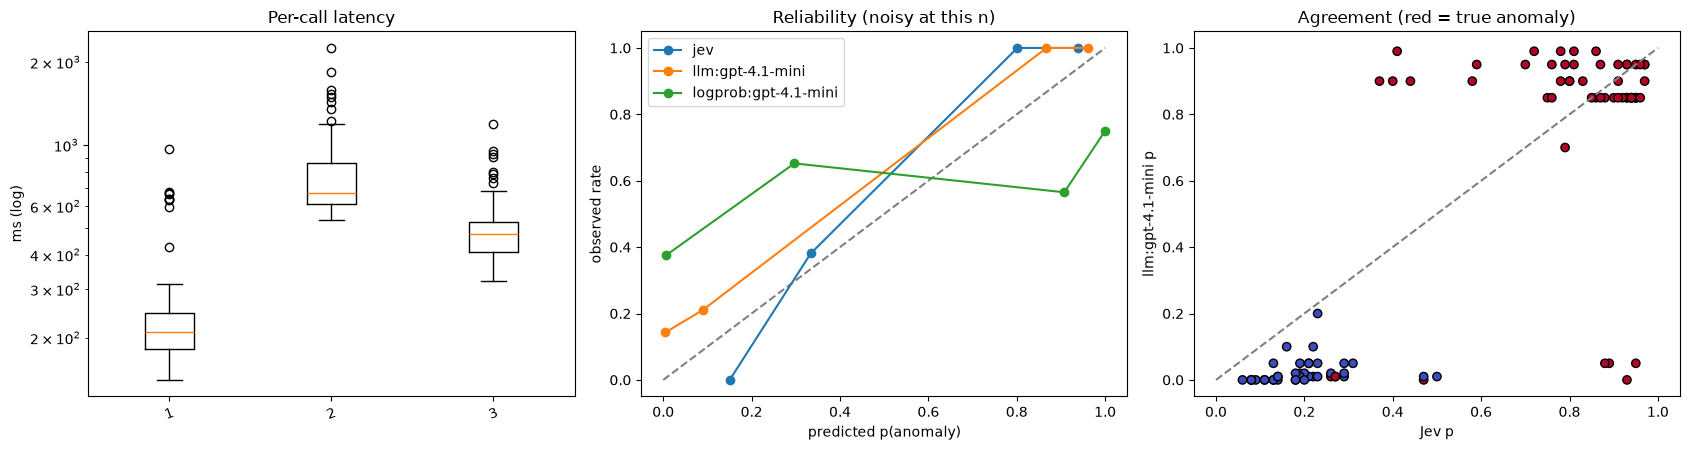

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
order = list(METHODS)

axes[0].boxplot([results[results.method == m].latency_ms for m in order], label=[m.split("/")[-1] for m in order])
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_yscale("log"); axes[0].set_ylabel("ms (log)"); axes[0].set_title("Per-call latency")

axes[1].plot([0, 1], [0, 1], "--", c="grey")
for m in order:
    g = results[(results.method == m)].dropna(subset=["p_anomaly"])
    fp, mp = calibration_curve(g.label, g.p_anomaly, n_bins=4, strategy="quantile")
    axes[1].plot(mp, fp, "o-", label=m)
axes[1].set_xlabel("predicted p(anomaly)"); axes[1].set_ylabel("observed rate"); axes[1].legend()
axes[1].set_title("Reliability (noisy at this n)")

wide = results.pivot_table(index=results.groupby("method").cumcount(), columns="method", values="p_anomaly")
lab = cases_df.label.values
axes[2].scatter(wide["jev"], wide[MAIN_LLM], c=lab, cmap="coolwarm", edgecolor="k")
axes[2].plot([0, 1], [0, 1], "--", c="grey"); axes[2].set_xlabel("Jev p"); axes[2].set_ylabel(f"{MAIN_LLM} p")
axes[2].set_title("Agreement (red = true anomaly)")
plt.tight_layout(); plt.show()

## 11. Where do they disagree

In [ ]:
cmp = cases_df[["domain", "label", "exp_type"]].copy()
cmp["case"] = [as_text(c["state"]).replace("\n", " ")[:140] + "…" for c in CASES]
for m in METHODS:
    sub = results[results.method == m].reset_index(drop=True)
    cmp[f"p_{m}"] = sub.p_anomaly.round(3)
    if not m.startswith("logprob:"):
        cmp[f"type_{m}"] = sub.type; cmp[f"sev_{m}"] = sub.severity

wrong = lambda col: ((cmp[col] >= .5).astype(int) != cmp.label)
cmp["jev_wrong"], cmp["llm_wrong"] = wrong("p_jev"), wrong(f"p_{MAIN_LLM}")
flag = cmp.jev_wrong | cmp.llm_wrong | ((cmp.p_jev - cmp[f"p_{MAIN_LLM}"]).abs() > .4)
pd.set_option("display.max_colwidth", 120)
display(cmp[flag])
print(f"Severity agreement (Jev vs {MAIN_LLM}): {(cmp.sev_jev == cmp[f'sev_{MAIN_LLM}']).mean():.0%}")

,domain,label,exp_type,case,p_jev,type_jev,sev_jev,p_llm:gpt-4.1-mini,type_llm:gpt-4.1-mini,sev_llm:gpt-4.1-mini,p_logprob:gpt-4.1-mini,jev_wrong,llm_wrong
3,labs,1,critical_value,"{""patient"": {""age"": 30, ""sex"": ""M"", ""history"": [""type 1 diabetes""]}, ""results"": {""glucose"": ""42 mg/dL""}, ""note"": ""sw...",0.41,critical_value,critical,0.99,critical_value,critical,0.731,True,False
14,vitals,1,deterioration,"{""patient"": {""age"": 68, ""context"": ""COPD exacerbation""}, ""readings"": [{""t"": ""06:00"", ""RR"": 18, ""SpO2"": 96, ""O2"": ""2 ...",0.37,deterioration,high,0.90,deterioration,high,0.999,True,False
22,meds,1,dosing_error,"{""patient"": {""age"": 60, ""weight_kg"": 70, ""allergies"": [], ""conditions"": [""rheumatoid arthritis""]}, ""order"": ""methotr...",0.40,dosing_error,none,0.90,dosing_error,high,0.996,True,False
23,meds,1,allergy_contraindication,"{""patient"": {""age"": 34, ""weight_kg"": 65, ""allergies"": [""penicillin - anaphylaxis""], ""conditions"": [""sinusitis""]}, ""o...",0.93,allergy_contraindication,critical,0.00,none,none,1.000,False,True
30,meds,1,dosing_error,"{""patient"": {""age"": 50, ""weight_kg"": 72, ""allergies"": [], ""conditions"": [""type 2 diabetes, insulin-naive""]}, ""order""...",0.47,dosing_error,none,0.00,none,none,0.000,True,True
38,discharge,0,none,Patient: 81-year-old woman. Admitted: 08/09/2026. Discharged: 19/09/2026. Diagnosis: Left intracapsular neck of femu...,0.47,none,none,0.01,none,none,0.953,False,False
51,discharge,1,medication_error,Patient: 61-year-old man. Admitted: 14/09/2026. Discharged: 18/09/2026. Diagnosis: Inferior STEMI; primary PCI with ...,0.26,none,high,0.01,none,none,0.996,True,True
55,discharge,1,medication_error,Patient: 80-year-old woman with type 2 diabetes and CKD. Admitted: 13/09/2026. Discharged: 18/09/2026. Diagnosis: Ac...,0.89,medication_error,high,0.05,none,none,0.679,False,True
68,discharge,0,none,Patient: 81-year-old woman. Admitted: 08/09/2026. Discharged: 19/09/2026. Diagnosis: Left intracapsular neck of femu...,0.50,none,none,0.01,none,none,0.971,True,False
81,discharge,1,medication_error,Patient: 61-year-old man. Admitted: 14/09/2026. Discharged: 18/09/2026. Diagnosis: Inferior STEMI; primary PCI with ...,0.27,none,high,0.01,none,none,0.993,True,True


Severity agreement (Jev vs llm:gpt-4.1-mini): 44%


## 12. Stability

In [ ]:
N_REPEAT, SAMPLE = 3, CASES[::4]
stab = []
for name in ["jev", MAIN_LLM]:
    for i, c in enumerate(SAMPLE):
        ps = [METHODS[name](c)["p_anomaly"] for _ in range(N_REPEAT)]
        stab.append({"method": name, "case": i, "std": float(np.std(ps)), "range": max(ps) - min(ps)})
display(pd.DataFrame(stab).groupby("method")[["std", "range"]].mean().round(4))

,std,range
method,,
jev,0.0051,0.0108
llm:gpt-4.1-mini,0.0033,0.0071


In [ ]:
cases_df

,domain,state,label,exp_type
0,labs,"{'patient': {'age': 45, 'sex': 'F', 'history': []}, 'results': {'Na': '139 mmol/L', 'K': '4.2 mmol/L', 'creatinine':...",0,none
1,labs,"{'patient': {'age': 67, 'sex': 'M', 'history': ['hypertension']}, 'results': {'K': '6.8 mmol/L', 'creatinine': '3.4 ...",1,critical_value
2,labs,"{'patient': {'age': 78, 'sex': 'F', 'history': ['on thiazide']}, 'results': {'Na': '118 mmol/L'}, 'note': 'new confu...",1,critical_value
3,labs,"{'patient': {'age': 30, 'sex': 'M', 'history': ['type 1 diabetes']}, 'results': {'glucose': '42 mg/dL'}, 'note': 'sw...",1,critical_value
4,labs,"{'patient': {'age': 58, 'sex': 'M', 'history': ['peptic ulcer']}, 'results': {'Hb': '6.1 g/dL'}, 'previous': {'Hb': ...",1,significant_trend
...,...,...,...,...
89,discharge,Patient: 74-year-old man. Admitted: 14/09/2026. Discharged: 11/09/2026. Length of stay: 3 days.\nDiagnosis: Syncope ...,1,documentation_inconsistency
90,discharge,"Patient: 66-year-old man, 40 pack-year smoker. Admitted: 16/09/2026. Discharged: 19/09/2026.\nDiagnosis: Left renal ...",1,missing_follow_up
91,discharge,"Patient: 71-year-old woman. Admitted: 21/09/2026. Discharged: 23/09/2026.\nDiagnosis: Fever of uncertain source, res...",1,missing_follow_up
92,discharge,"Patient: 59-year-old man, mechanical mitral valve replacement 2024 (reason warfarin chosen). Admitted: 18/09/2026. D...",1,missing_follow_up


In [ ]:
# from typesafe_sdk import Choice, TypeSafeClient

# with TypeSafeClient() as client:
#     response = client.system_one(
#         state={"document": "I was charged twice. Please fix this ASAP."},
#         questions={
#             "category": Choice(
#                 instructions="What is this ticket about?",
#                 criteria={"billing": None, "technical": None, "other": None},
#             ),
#         },
#     )

# print(response.choices["category"].choice)